# (04) lin + vh + gaussian + relu

**Motivation**: host = ```chewie```, device = ```cuda:0``` <br>

In [1]:
# HIDE CODE


import os, sys
from IPython.display import display

# tmp & extras dir
git_dir = os.path.join(os.environ['HOME'], 'Dropbox/git')
extras_dir = os.path.join(git_dir, 'jb-progress-2025/_extras')
fig_base_dir = os.path.join(git_dir, 'jb-progress-2025/figs')
tmp_dir = os.path.join(git_dir, 'jb-progress-2025/tmp')

# GitHub
sys.path.insert(0, os.path.join(git_dir, '_iclr_ipvae'))
from figures.convergence import plot_convergence
from main.config_defaults import default_configs
from figures.fighelper import *
from main.train import *

# warnings, tqdm, & style
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
from rich.jupyter import print
%matplotlib inline
set_style()

In [2]:
device_idx = 0
device = f'cuda:{device_idx}'

print(f"device: {device}  ———  host: {os.uname().nodename}")

device: cuda:0  ———  host: chewie

## configs

In [3]:
model_type = 'gaussian'
cfg_vae, cfg_tr = default_configs('vH16-wht', model_type, 'ngd|lin')

t_train = 16

cfg_vae['t_train'] = t_train
cfg_vae['kl_beta'] = 1/16 * t_train
cfg_vae['latent_act'] = 'relu'

cfg_vae['track_stats'] = True

### Make model + trainer

In [4]:
model = MODEL_CLASSES[model_type](CFG_CLASSES[model_type](**cfg_vae))
tr = Trainer(model, ConfigTrain(**cfg_tr), device=device)

tr.n_iters

154500

### Print info

+-------------+------------+
| Module Name | Num Params |
+-------------+------------+
|    IGVAE    |  133.1 K   |
|     ———     |    ———     |
|    layer    |  133.1 K   |
+-------------+------------+

gaussian+relu_vH16-wht_t-16_b-1_k-512_mse_<ngd|lin>
b200-ep300-lr(0.001)_gr(200)_(2025_06_03,19:10)

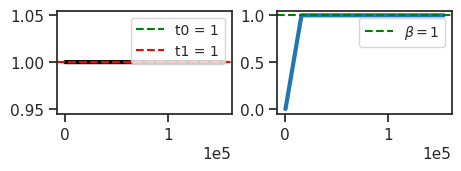

In [5]:
model.print()
tr.print()
tr.show_schedules()

In [6]:
# model.layer.n_exp

In [7]:
print(f"{vars(tr.model.cfg)}\n\n\n{vars(tr.cfg)}")

{'_type': 'gaussian', 'latent_act': 'relu', 't_train': 16, 'kl_beta': 1.0, 'n_latents': 512, 'enc_type': 'ngd', 
'dec_type': 'lin', 'recon_mode': 'mse', 'dataset': 'vH16-wht', 'dataset_name': 'vH16-wht', 'feeder': 'stationary', 
'feeder_cfg': {}, 'input_sz': (1, 16, 16), 'shape': (-1, 1, 16, 16), 'init_dist': 'normal', 'init_scale': 0.0001, 
'clamp_vals': {'u': (7.0, 2.0), 'du': (7.0, 3.0), 'dec': 3.45}, 'optim_sigma': False, 'stochastic': True, 
'fit_prior': True, 'seed': 0, 'track_stats': True, 'base_dir': '/home/hadi/Projects/PoissonVAE', 'data_dir': 
'/home/hadi/Datasets', 'runs_dir': 
'/home/hadi/Projects/PoissonVAE/runs/gaussian+relu_vH16-wht_t-16_b-1_k-512_mse_<ngd|lin>', 'mods_dir': 
'/home/hadi/Projects/PoissonVAE/models/gaussian+relu_vH16-wht_t-16_b-1_k-512_mse_<ngd|lin>', 'results_dir': 
'/home/hadi/Projects/PoissonVAE/results'}


{'lr': 0.001, 'epochs': 300, 'batch_size': 200, 'dataset_kws': None, 'warm_restart': 0, 'warmup_portion': 0.005, 
'optimizer': 'adamax_fast', 'optimizer_kws': {'weight_decay': 0.001, 'betas': (0.9, 0.999), 'eps': 1e-08}, 
'scheduler_type': 'cosine', 'scheduler_kws': {'T_max': 298.5, 'eta_min': 1e-05}, 'ema_rate': None, 'grad_clip': 
200, 'chkpt_freq': 50, 'eval_freq': 20, 'log_freq': 10, 'kl_beta_min': 0.0001, 'kl_const_portion': 0.001, 
'kl_anneal_portion': 0.1, 'temp_anneal_portion': 0.0, 'temp_anneal_type': 'lin', 'temp_start': 1.0, 'temp_stop': 
1.0}

In [8]:
print(tr.model.layer)

GaussianReluLayer(latent_dim=512, input_dim=256, temp=1)

### Fit model

In [9]:
tr.train('gold-vh')

Warning: Could not save code info: Reference at 'refs/heads/main' does not exist

epoch # 300, avg loss: 84.521: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 300/300 [1:48:35<00:00, 21.72s/it]


100%|███████████████████████████████████| 2/2 [00:03<00:00,  1.53s/it]


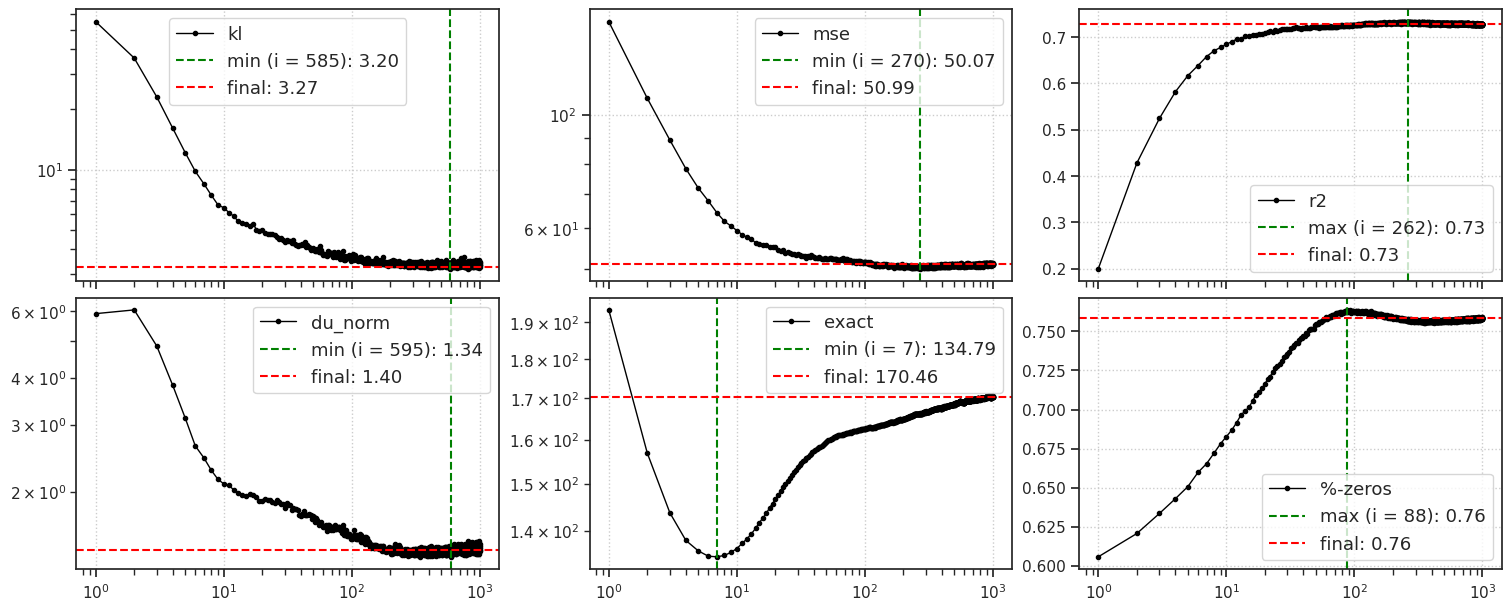

CPU times: user 5.52 s, sys: 212 ms, total: 5.73 s
Wall time: 5.73 s


In [11]:
%%time


results = tr.analysis(
    dl='vld',
    t_total=1000,
    n_data_batches=2,
)
_ = plot_convergence(results, color='k')

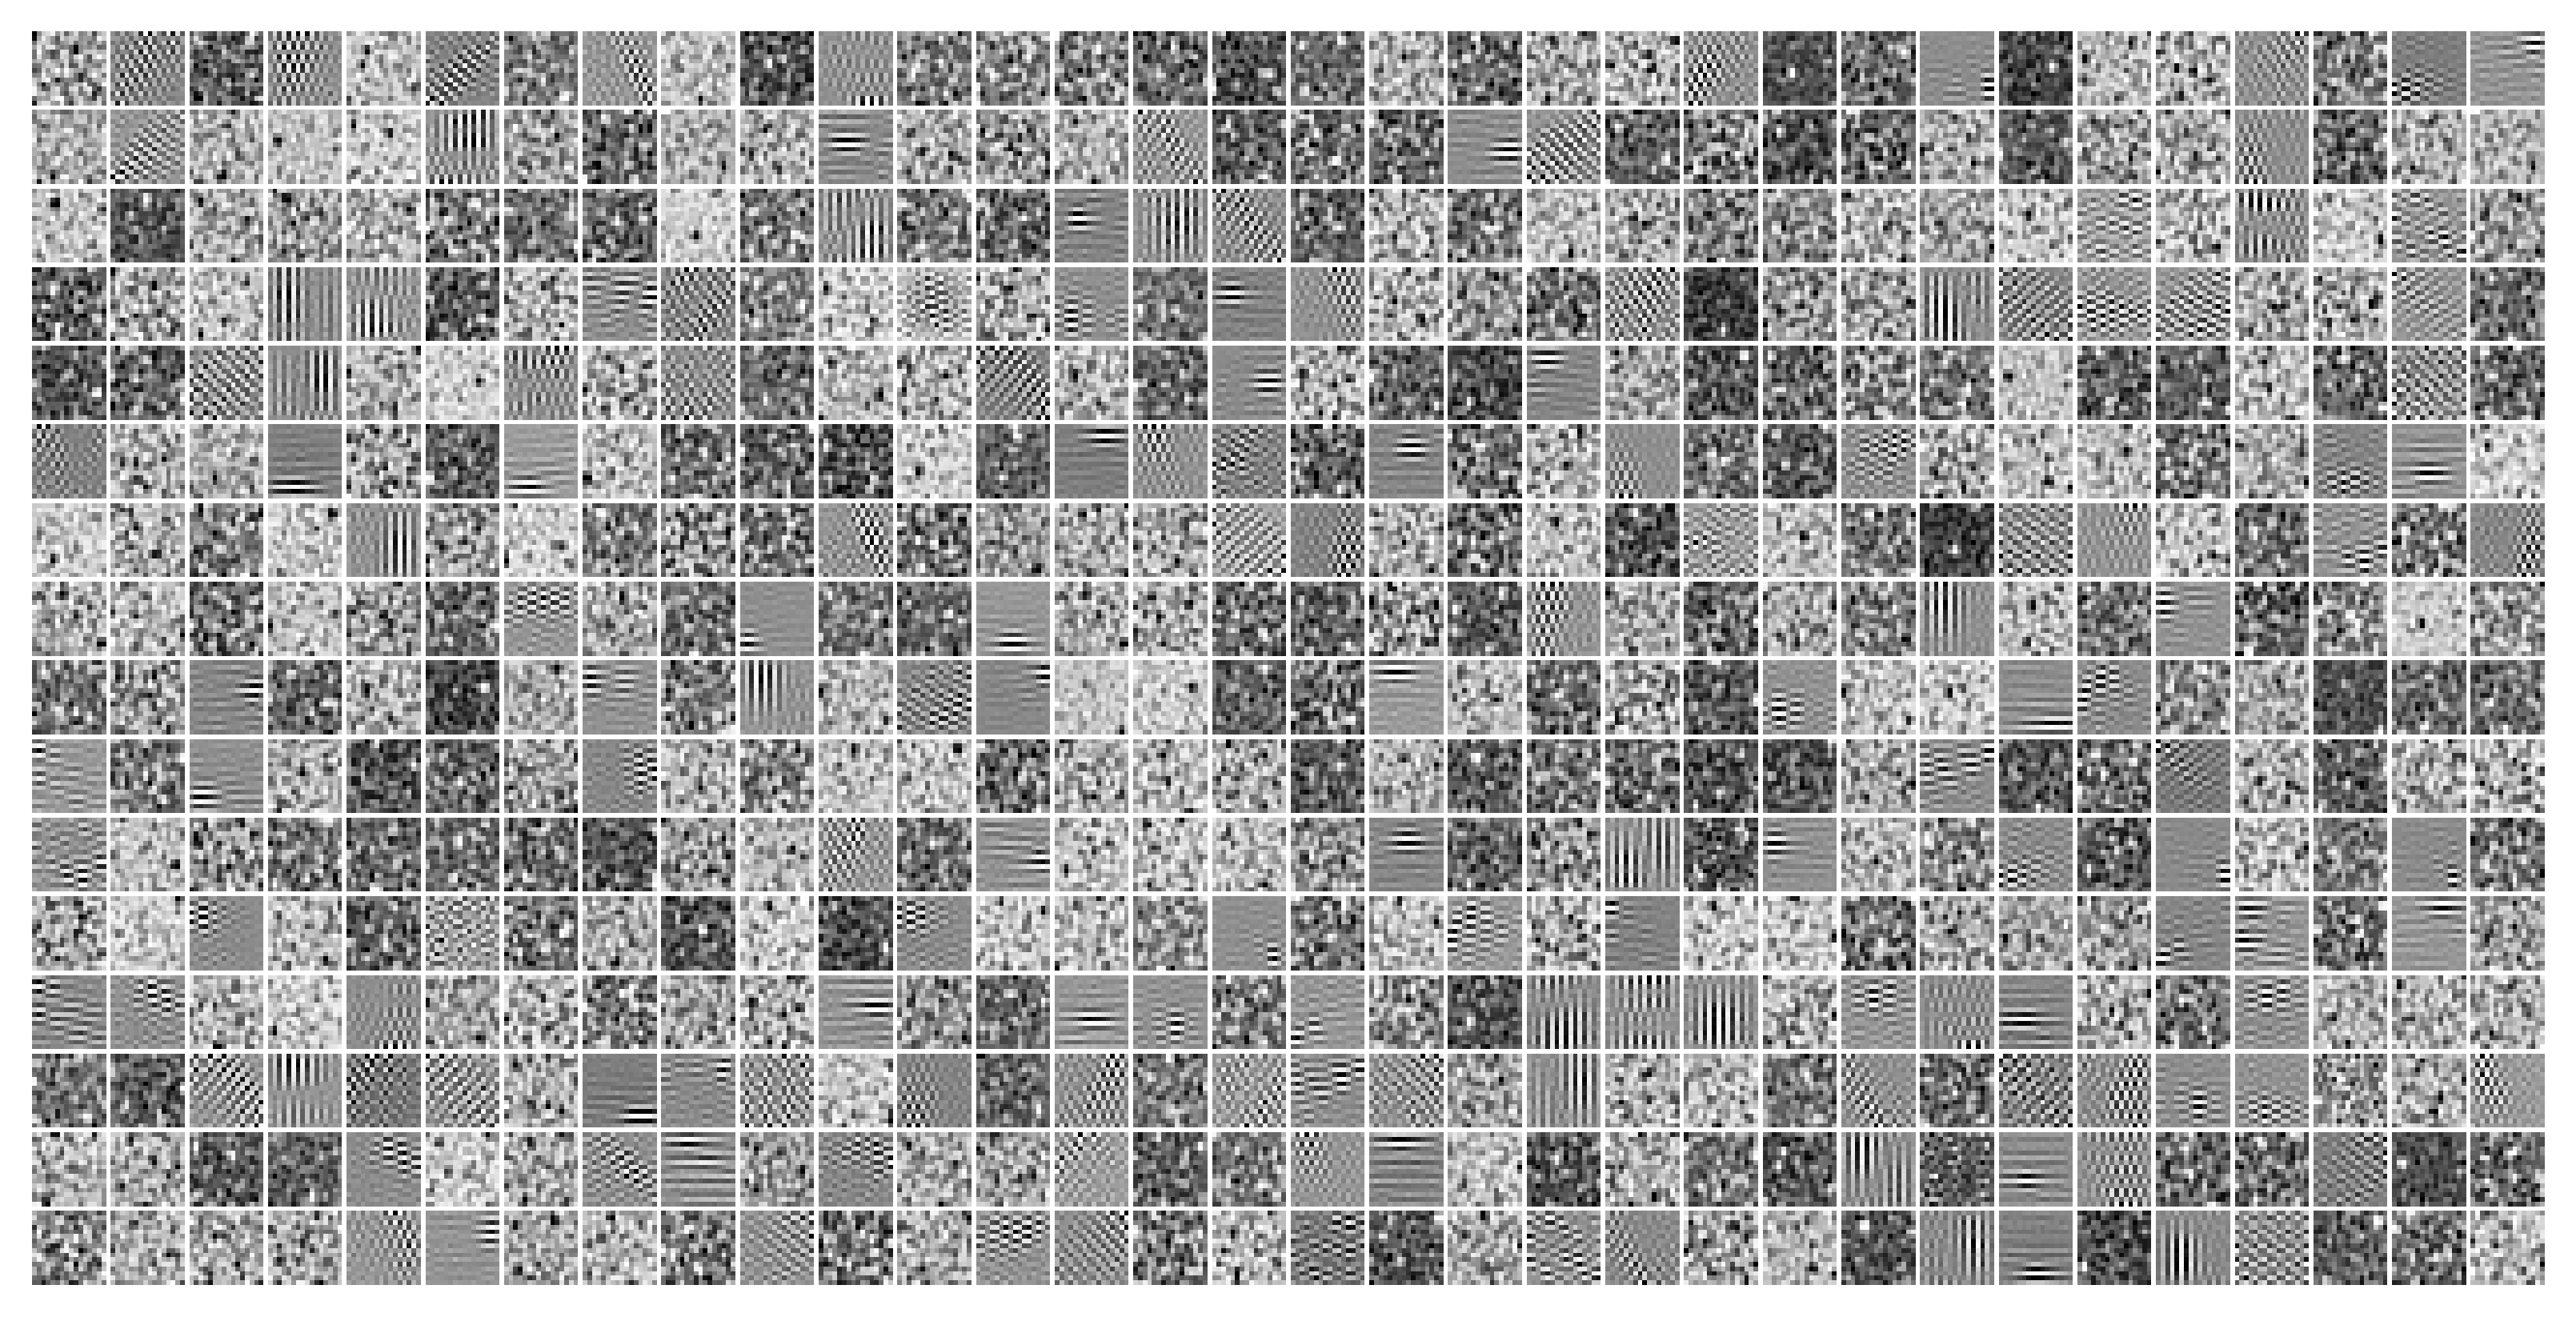

In [12]:
# u0 = tonp(tr.model.layer.u_init[0].squeeze())
# tr.model.show(order=np.argsort(u0), dpi=400, pad=1)
tr.model.show(order=None, dpi=400, pad=1);

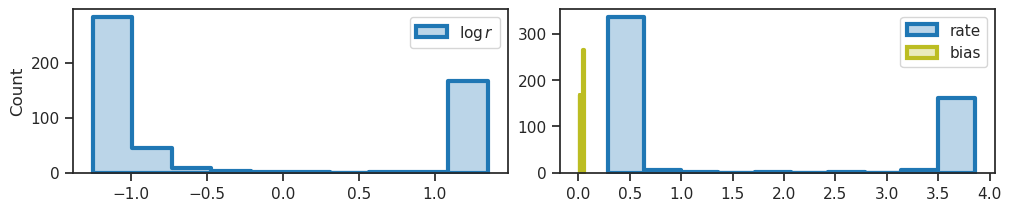

In [13]:
u0 = tonp(tr.model.layer.u_init[0].squeeze())
bias = tonp(tr.model.layer.log_bias.exp().squeeze())

fig, axes = create_figure(1, 2, (10, 2))
kws = dict(fill=True, lw=3, alpha=0.3, ax=axes[0])
sns.histplot(u0, color='C0', element='step', label=r'$\log r$', **kws)

kws = dict(fill=True, lw=3, alpha=0.3, ax=axes[1])
sns.histplot(np.exp(u0), color='C0', element='step', label='rate', **kws)
sns.histplot(bias, color='C8', element='step', label='bias', **kws)

axes[1].set(ylabel='')
add_legend(axes)

plt.show()

In [14]:
(bias > 0).mean()

1.0

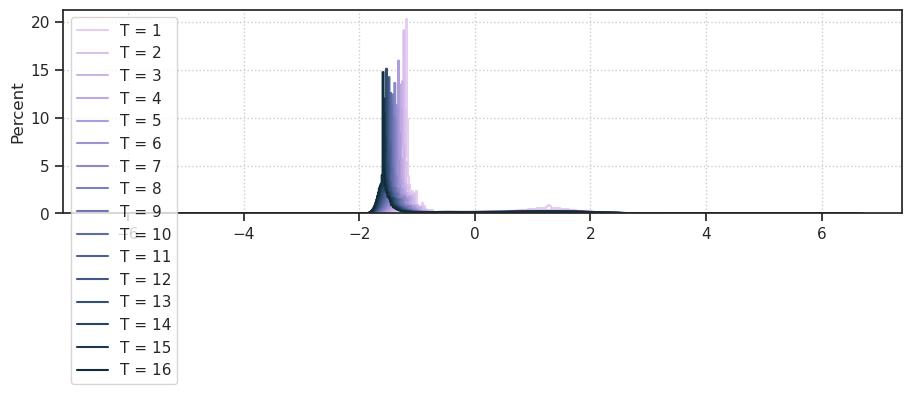

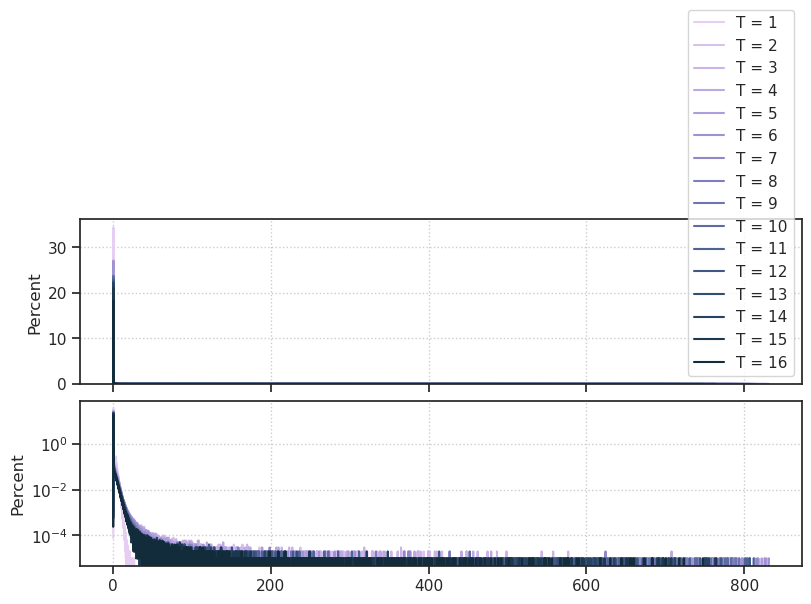

In [15]:
mult = 1

results = tr.xtract_ftr(
    t_total=tr.model.cfg.t_train * mult,
    save_freq=mult,
    n_data_batches=10,
    data_batch_sz=2000,
    verbose=False,
)


fig, ax = create_figure(1, 1, (9, 3.5))
pal = get_cubehelix_palette(len(results['times']), start=2.5)

for i, t in enumerate(results['times']):
    sns.histplot(
        results['state_0'][:, i].ravel(),
        stat='percent',
        element='step',
        fill=False,
        color=pal[i],
        label=f"T = {t}",
        ax=ax,
    )
ax.legend(loc='upper left')
ax.grid()
plt.show()


fig, axes = create_figure(2, 1, (8, 5.8), sharex='col')
for i, t in enumerate(results['times']):
    for ax in axes.flat:
        sns.histplot(
            np.exp(results['state_0'][:, i].ravel()),
            stat='percent',
            element='step',
            fill=False,
            color=pal[i],
            label=f"T = {t}",
            ax=ax,
        )
axes[0].legend()
axes[1].set(yscale='log')
add_grid(axes)
plt.show()

In [16]:
pal

[[0.8975507056831679, 0.8094812603307622, 0.9465577040964425],
 [0.8515783738056356, 0.7564048283277753, 0.9288121656434397],
 [0.8001162997533571, 0.7065759994349422, 0.9086196217899796],
 [0.7439792688412662, 0.6597624126404706, 0.8850042329763351],
 [0.6840855914209351, 0.6156494043651438, 0.8571492616027769],
 [0.621433610824204, 0.5738491579616475, 0.8244120665462615],
 [0.5570770035644698, 0.5339111022656235, 0.7863356920291484],
 [0.492099275511766, 0.4953333844045368, 0.7426568873299215],
 [0.4329197631622217, 0.4607041459016169, 0.6976371711644715],
 [0.36977282720352517, 0.4231998490866888, 0.6432078123635816],
 [0.3090934491249027, 0.3854178083786437, 0.5835384610223103],
 [0.2518347737894646, 0.34677973827838704, 0.5191313564287725],
 [0.1988566031415065, 0.30672139603456333, 0.45066798941042246],
 [0.1509035696744471, 0.2647062105047458, 0.3789955286940389],
 [0.10858527424075325, 0.22023851706947215, 0.30511000295886687],
 [0.07235872150128392, 0.17287618251766537, 0.23013648857700542]]

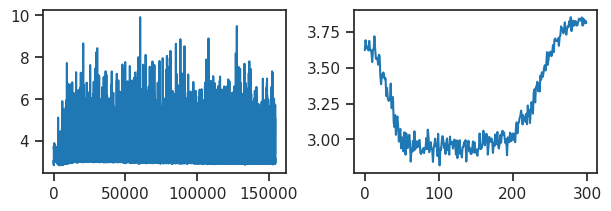

In [17]:
grad = np.array(list(tr.stats['grad'].values()))

fig, axes = create_figure(1, 2)
axes[0].plot(np.log(grad))
axes[1].plot(np.log(grad)[:300]);

In [18]:
(grad > 100).sum()

1476

100%|███████████████████████████████| 130/130 [03:16<00:00,  1.51s/it]


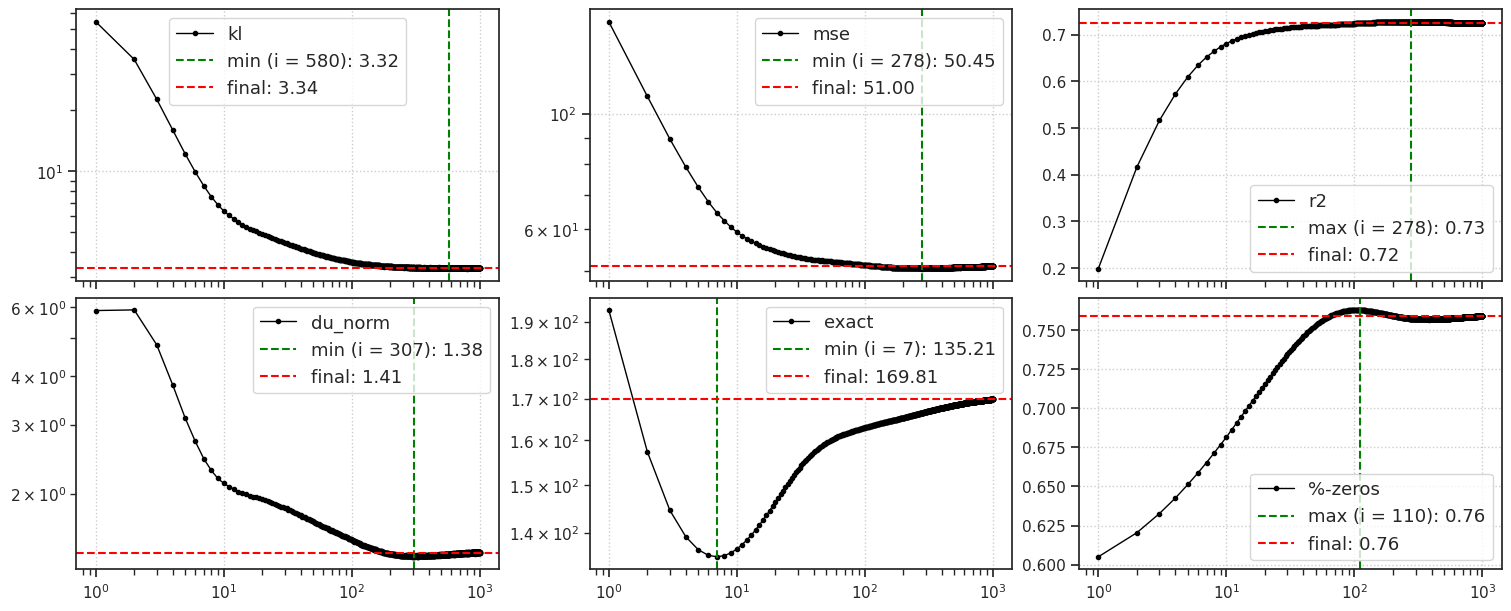

CPU times: user 4min 24s, sys: 9.6 s, total: 4min 34s
Wall time: 4min 34s


In [19]:
%%time


results = tr.analysis(
    dl='vld',
    t_total=1000,
    n_data_batches=-1,
)
_ = plot_convergence(results, color='k')